In [1]:
import numpy as np

In [2]:
from PIL import Image
import cv2

In [3]:
import form_parser
import image_builder
from image_builder import ARUCO_DICT

In [4]:
import math

In [94]:
image = form_parser.convert_pil_to_opencv(Image.open('../data/bad_image_02.jpg'))

In [95]:
# Convert to grayscale, and feed to the detector
as_grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# as_grayscale = cv2.GaussianBlur(as_grayscale, (5, 5), 0)

In [107]:
markers: list[tuple[np.ndarray, np.ndarray]] = []
mod_image = as_grayscale.copy()
marker_tl_found = False    # for debugging
any_markers_found = False  # for debugging
max_num_markers_found = -1 # for debugging
for rotation_deg in [0, 15, 30, 45, -15, -30, -45]:
    if rotation_deg:
        mod_image = form_parser.rotate_image(as_grayscale, rotation_deg)
    markers = form_parser.detect_markers(mod_image)

    max_num_markers_found = max(len(markers), max_num_markers_found)
    if markers:
        any_markers_found = True
        if any(l == 0 for (l, _) in markers):
            marker_tl_found = True
            break


In [108]:
max_num_markers_found

4

In [109]:
# Straighten out image given the top left corner marker (always label 0)
candidates = [c for (l, c) in markers if l == 0]
if not candidates:
    msg = "Unable to parse form: "

    if not any_markers_found:
        msg = msg + "no markers found"
    elif not marker_tl_found:
        msg = msg + f"found up to {max_num_markers_found}, but never the top left marker"
    else:
        msg = msg + "found markers, and found top left marker; some other error"

    raise form_parser.FormParserException(msg)

label_0_corners = candidates[0]
mod_image = form_parser.fix_rotation_given_marker(mod_image, label_0_corners)
# mod_image = crop_border(mod_image)
markers = form_parser.detect_markers(mod_image)

In [111]:
if len(markers) != 4:
    raise form_parser.FormParserException(f"Unable to parse form: found {len(markers)}; expected 4")

FormParserException: Unable to parse form: found 3; expected 4

In [113]:
parameters =  cv2.aruco.DetectorParameters()
corners, labels, r = (
    cv2.aruco.ArucoDetector(form_parser.ARUCO_DICT, parameters)
    .detectMarkers(mod_image)
)

In [114]:
frame_markers = cv2.aruco.drawDetectedMarkers(mod_image.copy(), corners, labels)

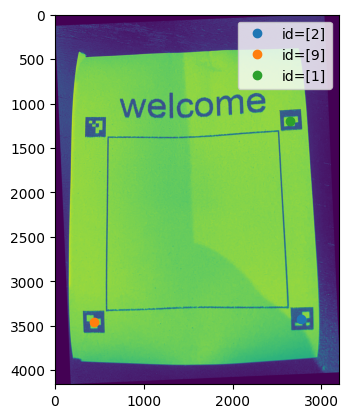

In [115]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(frame_markers)
for i in range(len(labels)):
    c = corners[i][0]
    plt.plot([c[:, 0].mean()], [c[:, 1].mean()], "o", label = "id={0}".format(labels[i]))
plt.legend()
plt.show()

In [105]:

# Reorder markers to be (tl, tr, br, bl)
labels, corners = zip(*reorder_markers(markers))

# Identify the inner corners of each marker (the drawing's frame)
# Remember ARUCO detector returns corners in order (tl, tr, br, bl)
frame_boundaries = np.array([
    corners[0][:, 2],
    corners[1][:, 3],
    corners[2][:, 0],
    corners[3][:, 1],
]).squeeze().astype(np.float32)

# Identify the points we want to transform it to (handles warp & scale)
tgt_points = np.array([
    [0, 0],
    [transformed_size, 0],
    [transformed_size, transformed_size],
    [0, transformed_size],
]).astype(np.float32)

transformation = cv2.getPerspectiveTransform(
    frame_boundaries.squeeze(),
    tgt_points,
)

# Apply all transformations to original image
if rotation_deg:
    image = rotate_image(image, rotation_deg)
image = fix_rotation_given_marker(image, label_0_corners)
return cv2.warpPerspective(
    image,
    transformation,
    (transformed_size, transformed_size),
), [x.item() for x in labels]



IndexError: list index out of range

In [116]:
import image_builder

In [118]:
a = image_builder.build_titled_card("welcome", "/System/Library/Fonts/Supplemental/Arial.ttf", (1, 2, 15))

In [120]:
Image.fromarray(a).save("../data/mad.jpg")

In [121]:
import sqlite3

In [123]:
conn = sqlite3.connect('../test.db')

In [125]:
res = conn.execute(
    """
    SELECT
        game.length AS gameLength,
        drawing.drawingNumber AS drawingNumber
    FROM
        game
            LEFT JOIN
        drawing
            ON
        game.id = drawing.gameId
    WHERE
        drawing.id = ?
    """,
    (1, ),
)

record = res.fetchone()

if record is None:
    raise Exception("Drawing not found")


In [130]:
res = conn.execute("UPDATE game SET length = 2;")

In [131]:
conn.commit()

In [149]:
# res = conn.execute("SELECT * FROM game;")
res = conn.execute("SELECT * FROM drawing WHERE gameId = 1 AND submittedAt IS NULL;")

In [150]:
res.fetchall()

[(4, 1, 2, 1036281, None, 1780433663, None)]

In [147]:
conn.execute("UPDATE drawing SET id = 4 WHERE id = 5;")

In [148]:
conn.commit()

In [151]:
help(Image.open)

Help on function open in module PIL.Image:

open(fp: 'StrOrBytesPath | IO[bytes]', mode: "Literal['r']" = 'r', formats: 'list[str] | tuple[str, ...] | None' = None) -> 'ImageFile.ImageFile'
    Opens and identifies the given image file.

    This is a lazy operation; this function identifies the file, but
    the file remains open and the actual image data is not read from
    the file until you try to process the data (or call the
    :py:meth:`~PIL.Image.Image.load` method).  See
    :py:func:`~PIL.Image.new`. See :ref:`file-handling`.

    :param fp: A filename (string), os.PathLike object or a file object.
       The file object must implement ``file.read``,
       ``file.seek``, and ``file.tell`` methods,
       and be opened in binary mode. The file object will also seek to zero
       before reading.
    :param mode: The mode.  If given, this argument must be "r".
    :param formats: A list or tuple of formats to attempt to load the file in.
       This can be used to restrict t

In [155]:
res = [x[0] for x in conn.execute("""SELECT imageData FROM drawing ORDER BY id;""").fetchall()]

In [156]:
import io

In [162]:
Image.open(io.BytesIO(res[0]), formats=("JPEG", "HEIF"))

KeyError: 'HEIF'

In [172]:
from importlib import reload

In [173]:
reload(form_parser)
reload(image_builder)

<module 'image_builder' from '/Users/anthonyliu/Projects/receipt-printer-exquisite-corpse/src/image_builder.py'>

In [176]:
form = image_builder.get_completed_game(res)

In [177]:
img = Image.fromarray(form, mode="RGB")


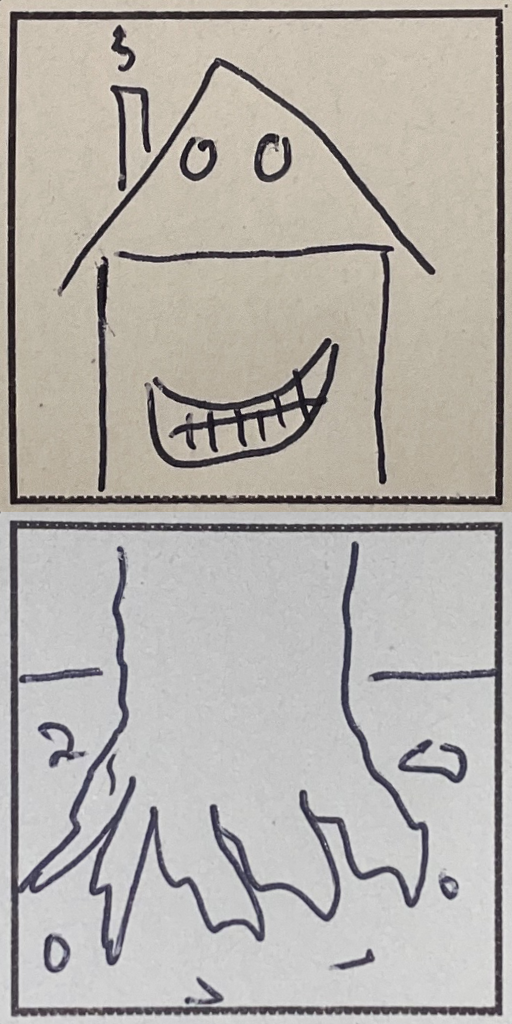

In [178]:
img

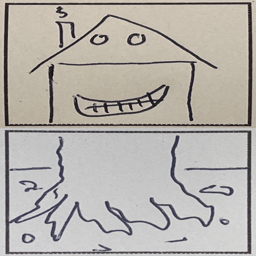

In [180]:
img.resize((256, 256))

In [ ]:
fobj = BytesIO()
img.save(fobj, format="jpeg")
fobj.seek(0)